In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error

plt.style.use('fivethirtyeight')

In [2]:
# Creating a dummy daily sales dataset for 2 years 
date_range = pd.date_range(start='2022-01-01', end='2023-12-31', freq='D')
sales_data = np.random.randint(100, 500, size=len(date_range)) + np.linspace(0, 100, len(date_range))

# Adding Seasonality (Sales increase on weekends)
df_sales = pd.DataFrame({'ds': date_range, 'y': sales_data})
df_sales['y'] = df_sales['y'] + (df_sales['ds'].dt.dayofweek // 5) * 50 

print("First 5 rows of time-series data:")
print(df_sales.head())

First 5 rows of time-series data:
          ds           y
0 2022-01-01  194.000000
1 2022-01-02  268.137174
2 2022-01-03  105.274348
3 2022-01-04  242.411523
4 2022-01-05  216.548697


In [3]:
# Train on data until Oct 2023, Test on last 3 months
train = df_sales[df_sales['ds'] < '2023-10-01']
test = df_sales[df_sales['ds'] >= '2023-10-01']

print(f"Training records: {len(train)}")
print(f"Testing records: {len(test)}")

Training records: 638
Testing records: 92


In [4]:
# Initialize Prophet with Seasonality components
model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    changepoint_prior_scale=0.05 # Adjusts how flexible the trend is
)

# Adding holiday or promotional effects (Optional but professional)
model.add_country_holidays(country_name='IN')

# Training the model
model.fit(train)

C:\Users\ajay\anaconda3\Lib\site-packages\holidays\countries\india.py:190: Warning: Requested Holidays are available only from 2001 to 2035.
  warnings.warn(warning_msg, Warning)
11:13:28 - cmdstanpy - INFO - Chain [1] start processing
11:13:29 - cmdstanpy - INFO - Chain [1] done processing


In [5]:
# Create a dataframe for the next 90 days
future = model.make_future_dataframe(periods=90)

# Predict
forecast = model.predict(future)

# Display relevant columns
print(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

            ds        yhat  yhat_lower  yhat_upper
723 2023-12-25  334.191278  186.355868  483.878057
724 2023-12-26  371.370727  221.156426  512.430588
725 2023-12-27  383.814584  229.291240  524.554417
726 2023-12-28  402.633111  265.735363  539.976179
727 2023-12-29  375.838798  236.327993  524.991004


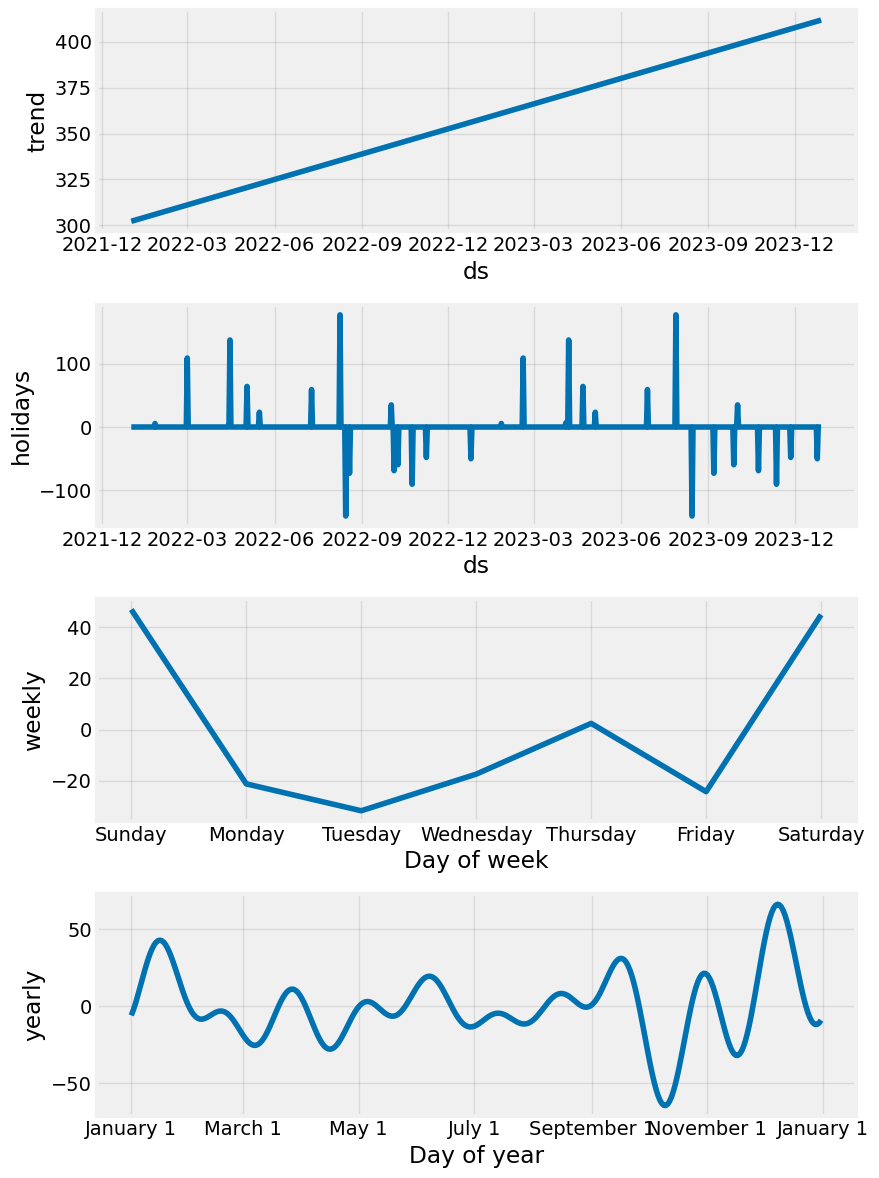

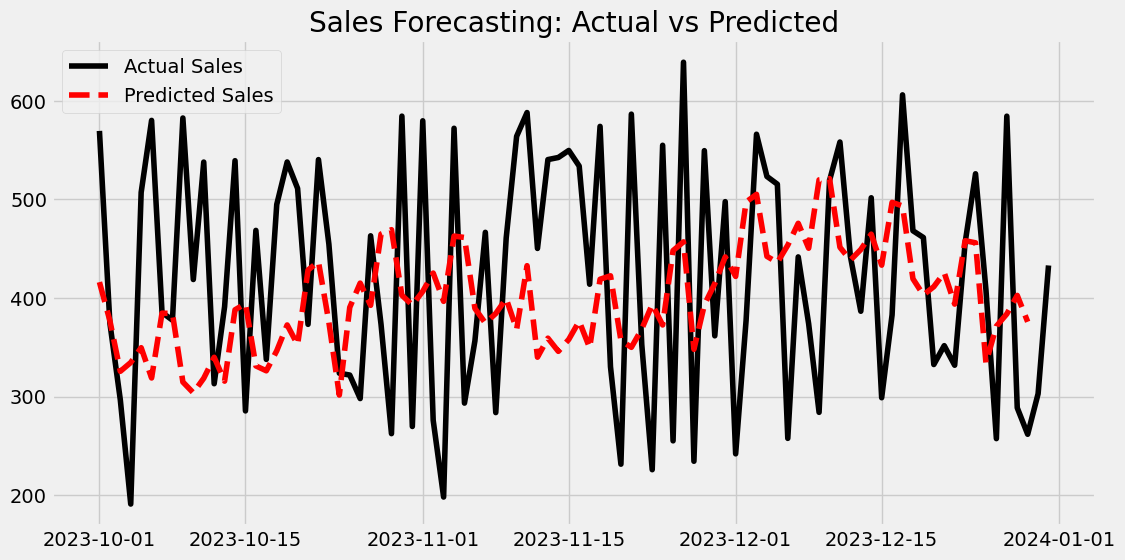

In [6]:
# Plotting the components (Trend, Weekly, Yearly)
fig1 = model.plot_components(forecast)
plt.show()

# Plotting Forecast vs Actual
plt.figure(figsize=(12, 6))
plt.plot(test['ds'], test['y'], label='Actual Sales', color='black')
plt.plot(forecast.loc[forecast['ds'] >= '2023-10-01', 'ds'], 
         forecast.loc[forecast['ds'] >= '2023-10-01', 'yhat'], 
         label='Predicted Sales', color='red', linestyle='--')
plt.title('Sales Forecasting: Actual vs Predicted')
plt.legend()
plt.show()

In [7]:
# Merge test and forecast data
performance = pd.merge(test, forecast[['ds', 'yhat']], on='ds')

# Calculate Errors
mae = mean_absolute_error(performance['y'], performance['yhat'])
mape = mean_absolute_percentage_error(performance['y'], performance['yhat'])

print(f"Mean Absolute Error (MAE): {round(mae, 2)}")
print(f"Mean Absolute Percentage Error (MAPE): {round(mape*100, 2)}%")

Mean Absolute Error (MAE): 113.09
Mean Absolute Percentage Error (MAPE): 29.25%
